# Stage 2: Chaos-MoE Architectural Variants

## Мотивация

Из [01](01_looped_chaos_prototype.ipynb) и [02](02_looped_chaos_scaled_residual.ipynb) выяснили:
- Proposition 3 математически верна (scaled residual bounded)
- **Looping per se не даёт ценности для SAE-компрессии** (loss строго хуже baseline)

Переходим к **композиции с MoE**. Гипотеза: chaos-активация решает проблему dead experts (как решает dead neurons в тестах 19-20).

## Варианты архитектуры (triage-ноутбук)

| # | Вариант | Seed-план | Ожидание |
|---|---|---|---|
| 1 | **Chaos-MoE Experts** — эксперты с chaos activation (рекомендованный) | 3 seeds | Primary candidate |
| 2 | **Hybrid Chaos+MoE** — chaos только в bottleneck, MoE стандартный | 1 seed | Фолбэк |
| 3 | **Chaos Router** — chaos в gating mechanism | 1 seed | Проверка load balancing |
| 4 | **Scaled Residual MoE** — MoE + α=1/T residual | 1 seed | Повторение 02-проблемы (контроль) |
| 5 | **Multi-Pass Refinement** — T отдельных проходов без weight sharing | 1 seed | Альтернатива looped |

**Цель:** понять, какой вариант дать фуллу 3-5 seed ablation в следующем ноутбуке.

## Метрики

Главные:
- `val_loss` (reconstruction MSE)
- `2-bit degradation %` — главный критерий quant-friendliness
- `dead_experts %` — новая метрика для MoE (сколько экспертов не выбирается)
- `expert_entropy` — load balancing (чем выше, тем лучше баланс)
- `latent_range` — проверка bounded prior

## Baseline reference

- V4 SAE (T=0 из 02): loss=0.169, 2-bit deg=+10.3%, dead=0
- TopK+ReLU SAE (тест 19): loss=0.156, 2-bit deg=+4.1%, dead=0 при K=10%

Наш порог GO: **val_loss ≤ 0.20 AND 2-bit deg ≤ 13%** для любого варианта.

In [1]:
import os
import json
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f'TF: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

ARCH_DIR = Path('.').resolve()
CACHE_DIR = ARCH_DIR / 'cache'
JSONS_DIR = ARCH_DIR.parent / 'jsons'

/Users/savenkovviktor/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TF: 2.16.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Загрузка активаций (из кэша 01)

In [2]:
ACTIVATION_DIM = 768
TARGET_LAYER = 6
N_TEXTS = 500

cache_file = CACHE_DIR / f'gpt2_layer{TARGET_LAYER}_n{N_TEXTS}.npy'
assert cache_file.exists(), f'Сначала запустите 01 для кэша {cache_file}'
activations = np.load(cache_file)

act_mean = activations.mean(axis=0, keepdims=True)
act_std = activations.std(axis=0, keepdims=True) + 1e-8
activations_norm = ((activations - act_mean) / act_std).astype('float32')

np.random.seed(42)
idx = np.random.permutation(len(activations_norm))
split = int(len(idx) * 0.8)
x_train = activations_norm[idx[:split]]
x_test = activations_norm[idx[split:]]

print(f'Train: {x_train.shape}, Test: {x_test.shape}')

Train: (43658, 768), Test: (10915, 768)


## 2. Общие компоненты

Chaos, KSparse, quantization — переиспользуются из 01/02.

In [3]:
def chaos_activation(x):
    return tf.sin(1.0 * x) + 0.5 * tf.tanh(4.0 * x)


class KSparseLayer(layers.Layer):
    def __init__(self, k=32, **kwargs):
        super().__init__(**kwargs)
        self.k = k

    def call(self, inputs):
        latent_dim = tf.shape(inputs)[1]
        _, indices = tf.nn.top_k(tf.abs(inputs), k=self.k, sorted=False)
        mask = tf.reduce_sum(tf.one_hot(indices, latent_dim, dtype=inputs.dtype), axis=1)
        return inputs * mask

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'k': self.k})
        return cfg


def quantize_latent(latents, bits):
    q = np.zeros_like(latents)
    levels = 2 ** bits - 1
    for i in range(latents.shape[0]):
        nz = np.where(np.abs(latents[i]) > 1e-10)[0]
        if len(nz) == 0:
            continue
        vals = latents[i, nz]
        vmin, vmax = vals.min(), vals.max()
        if vmax - vmin < 1e-10:
            q[i, nz] = vals
            continue
        norm = (vals - vmin) / (vmax - vmin)
        q[i, nz] = np.round(norm * levels) / levels * (vmax - vmin) + vmin
    return q

## 3. MoE building blocks

`ChaosExpert` — маленький FFN с chaos-активацией. `ChaosMoE` — sparse top-k routing с опцией chaos-router.

In [4]:
class ChaosExpert(layers.Layer):
    """Один expert: Dense -> chaos -> Dense. Bounded по construction."""
    def __init__(self, dim, inner_mult=2, use_chaos=True, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim
        self.inner_mult = inner_mult
        self.use_chaos = use_chaos
        self.dense_in = layers.Dense(dim * inner_mult)
        self.dense_out = layers.Dense(dim)

    def call(self, x):
        h = self.dense_in(x)
        h = chaos_activation(h) if self.use_chaos else tf.nn.gelu(h)
        return self.dense_out(h)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'dim': self.dim, 'inner_mult': self.inner_mult, 'use_chaos': self.use_chaos})
        return cfg


class ChaosMoE(layers.Layer):
    """Sparse top-k MoE с опциональным chaos-router и shared expert.
    
    use_chaos_experts: эксперты с chaos activation (Variant 1, 3)
                       False → стандартный GELU (Variant 2)
    use_chaos_router: router-logits пропускаются через chaos (Variant 3)
    scaled_residual: если True, выход = input + (1/top_k)·moe (Variant 4)
    """
    def __init__(self, dim, num_experts=8, top_k=2, inner_mult=2,
                 use_chaos_experts=True, use_chaos_router=False,
                 use_shared_expert=True, scaled_residual=False, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim
        self.num_experts = num_experts
        self.top_k = top_k
        self.inner_mult = inner_mult
        self.use_chaos_experts = use_chaos_experts
        self.use_chaos_router = use_chaos_router
        self.use_shared_expert = use_shared_expert
        self.scaled_residual = scaled_residual

        self.router = layers.Dense(num_experts)
        self.experts = [
            ChaosExpert(dim, inner_mult, use_chaos=use_chaos_experts, name=f'exp_{i}')
            for i in range(num_experts)
        ]
        if use_shared_expert:
            self.shared_expert = ChaosExpert(dim, inner_mult, use_chaos=use_chaos_experts, name='exp_shared')

    def call(self, x):
        logits = self.router(x)
        scores = chaos_activation(logits) if self.use_chaos_router else tf.nn.softmax(logits, axis=-1)

        topk_vals, topk_idx = tf.nn.top_k(scores, k=self.top_k, sorted=False)
        topk_vals = topk_vals / (tf.reduce_sum(tf.abs(topk_vals), axis=-1, keepdims=True) + 1e-8)

        all_outs = tf.stack([e(x) for e in self.experts], axis=1)  # [B, E, D]
        mask_hot = tf.one_hot(topk_idx, self.num_experts)  # [B, k, E]
        weights = tf.reduce_sum(mask_hot * tf.expand_dims(topk_vals, -1), axis=1)  # [B, E]
        routed = tf.reduce_sum(all_outs * tf.expand_dims(weights, -1), axis=1)

        if self.use_shared_expert:
            routed = routed + self.shared_expert(x)

        if self.scaled_residual:
            return x + (1.0 / self.top_k) * routed
        return routed

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            'dim': self.dim, 'num_experts': self.num_experts, 'top_k': self.top_k,
            'inner_mult': self.inner_mult,
            'use_chaos_experts': self.use_chaos_experts,
            'use_chaos_router': self.use_chaos_router,
            'use_shared_expert': self.use_shared_expert,
            'scaled_residual': self.scaled_residual,
        })
        return cfg


class MultiPassBlock(layers.Layer):
    """Variant 5: T отдельных chaos k-sparse проходов БЕЗ weight sharing."""
    def __init__(self, dim, k_active, T=2, alpha=0.5, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim
        self.k_active = k_active
        self.T = T
        self.alpha = alpha
        self.denses = [layers.Dense(dim, name=f'pass_dense_{i}') for i in range(T)]
        self.ksparses = [KSparseLayer(k=k_active, name=f'pass_ksparse_{i}') for i in range(T)]

    def call(self, inputs):
        z = inputs
        for dense, ks in zip(self.denses, self.ksparses):
            delta = chaos_activation(dense(z))
            z = ks(z + self.alpha * delta)
        return z

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'dim': self.dim, 'k_active': self.k_active, 'T': self.T, 'alpha': self.alpha})
        return cfg

## 4. Builders для каждого варианта

Общий шаблон: `Input → Dense → chaos → KSparse → [variant-specific block] → KSparse → Decoder`.

In [5]:
def build_baseline_v4(input_dim=768, latent_dim=3072, k_active=307):
    """T=0 V4 SAE (baseline ref, без MoE)."""
    inp = keras.Input(shape=(input_dim,))
    x = layers.Dense(latent_dim)(inp)
    x = layers.Activation(chaos_activation)(x)
    z = KSparseLayer(k=k_active)(x)
    enc = keras.Model(inp, z)
    ae = keras.Model(inp, layers.Dense(input_dim)(z))
    ae.compile(optimizer='adam', loss='mse')
    return ae, enc, None


def build_moe_sae(variant, input_dim=768, latent_dim=3072, k_active=307,
                  num_experts=8, top_k=2, inner_mult=2):
    """Универсальный builder для вариантов 1-4.
    
    variant ∈ {'V1_chaos_experts', 'V2_hybrid', 'V3_chaos_router', 'V4_scaled_moe'}
    """
    cfg = {
        'V1_chaos_experts':  dict(use_chaos_experts=True,  use_chaos_router=False, scaled_residual=False),
        'V2_hybrid':         dict(use_chaos_experts=False, use_chaos_router=False, scaled_residual=False),
        'V3_chaos_router':   dict(use_chaos_experts=True,  use_chaos_router=True,  scaled_residual=False),
        'V4_scaled_moe':     dict(use_chaos_experts=True,  use_chaos_router=False, scaled_residual=True),
    }[variant]

    inp = keras.Input(shape=(input_dim,))
    x = layers.Dense(latent_dim)(inp)
    x = layers.Activation(chaos_activation)(x)
    z0 = KSparseLayer(k=k_active, name='latent_ksparse_init')(x)

    moe = ChaosMoE(latent_dim, num_experts=num_experts, top_k=top_k,
                    inner_mult=inner_mult, use_shared_expert=True,
                    name='moe_block', **cfg)
    z = moe(z0)
    z = KSparseLayer(k=k_active, name='latent_ksparse_post')(z)

    enc = keras.Model(inp, z)
    ae = keras.Model(inp, layers.Dense(input_dim, name='decoder')(z))
    ae.compile(optimizer='adam', loss='mse')
    return ae, enc, moe


def build_multipass_sae(input_dim=768, latent_dim=3072, k_active=307, T=2, alpha=0.5):
    """Variant 5: multi-pass без weight sharing."""
    inp = keras.Input(shape=(input_dim,))
    x = layers.Dense(latent_dim)(inp)
    x = layers.Activation(chaos_activation)(x)
    z0 = KSparseLayer(k=k_active)(x)

    block = MultiPassBlock(latent_dim, k_active, T=T, alpha=alpha, name='multipass')
    z = block(z0)

    enc = keras.Model(inp, z)
    ae = keras.Model(inp, layers.Dense(input_dim)(z))
    ae.compile(optimizer='adam', loss='mse')
    return ae, enc, None

## 5. Evaluate function с MoE метриками

Дополнительно к базовым: `dead_experts` и `expert_entropy` (load balancing).

In [6]:
BITS_SWEEP = [2, 3, 4, 6, 8]


def extract_decoder(ae, latent_dim):
    """Выделяет последний Dense-слой (decoder) в standalone model."""
    dec_in = keras.Input(shape=(latent_dim,))
    # Ищем слой с именем 'decoder', иначе берём последний Dense
    dec_layer = None
    for layer in ae.layers:
        if layer.name == 'decoder':
            dec_layer = layer
            break
    if dec_layer is None:
        # Fallback: последний Dense в модели
        for layer in reversed(ae.layers):
            if isinstance(layer, layers.Dense):
                dec_layer = layer
                break
    if dec_layer is None:
        raise RuntimeError('decoder layer not found')
    return keras.Model(dec_in, dec_layer(dec_in))


def router_stats(ae, moe, x_sample):
    """Возвращает (dead_experts, expert_entropy) для MoE-модели."""
    try:
        # Получаем z0 — вход в MoE (после initial KSparse)
        z0_model = keras.Model(ae.input, ae.get_layer('latent_ksparse_init').output)
        z0 = z0_model.predict(x_sample, batch_size=512, verbose=0)
        router_logits = moe.router(tf.constant(z0)).numpy()
        if moe.use_chaos_router:
            scores = np.sin(router_logits) + 0.5 * np.tanh(4 * router_logits)
        else:
            e = np.exp(router_logits - router_logits.max(axis=-1, keepdims=True))
            scores = e / e.sum(axis=-1, keepdims=True)
        topk = np.argsort(scores, axis=-1)[:, -moe.top_k:]
        selections = np.bincount(topk.flatten(), minlength=moe.num_experts)
        dead_e = int(np.sum(selections == 0))
        p = selections / selections.sum()
        p = p[p > 0]
        ent = float(-np.sum(p * np.log(p)) / np.log(moe.num_experts))
        return dead_e, ent
    except Exception as e:
        print(f'  router analysis failed: {type(e).__name__}: {e}')
        return None, None


def evaluate_moe(build_fn, build_kwargs, seed=0, epochs=8, batch=256, verbose=True):
    np.random.seed(seed)
    tf.random.set_seed(seed)

    ae, enc, moe = build_fn(**build_kwargs)
    params = ae.count_params()
    hist = ae.fit(x_train, x_train, epochs=epochs, batch_size=batch,
                  validation_data=(x_test, x_test), verbose=0)
    val_loss = float(hist.history['val_loss'][-1])

    latents = enc.predict(x_test, batch_size=512, verbose=0)
    dead_lat = int(np.sum(np.all(np.abs(latents) < 1e-6, axis=0)))
    lat_var = float(latents.var())
    nz = latents[np.abs(latents) > 1e-10]
    lat_range = [float(nz.min()), float(nz.max())] if nz.size else [0.0, 0.0]

    decoder = extract_decoder(ae, latents.shape[1])
    quant = {}
    for bits in BITS_SWEEP:
        q_lat = quantize_latent(latents, bits)
        q_rec = decoder.predict(q_lat, batch_size=512, verbose=0)
        quant[bits] = float(np.mean((x_test - q_rec) ** 2))

    dead_experts, expert_entropy = (None, None)
    if moe is not None:
        dead_experts, expert_entropy = router_stats(ae, moe, x_test[:2000])

    r = {
        'seed': seed, 'params': params, 'val_loss': val_loss,
        'dead_latents': dead_lat, 'lat_var': lat_var, 'lat_range': lat_range,
        'dead_experts': dead_experts, 'expert_entropy': expert_entropy,
        'quant': quant,
    }
    if verbose:
        deg2 = (quant[2] - val_loss) / val_loss * 100
        de_str = f'dead_exp={dead_experts}' if dead_experts is not None else 'no_moe'
        ent_str = f'ent={expert_entropy:.2f}' if expert_entropy is not None else ''
        print(f'  seed={seed} params={params/1e6:.2f}M loss={val_loss:.4f} '
              f'dead_lat={dead_lat} {de_str} {ent_str} '
              f'range=[{lat_range[0]:+.2f},{lat_range[1]:+.2f}] 2-bit={deg2:+.1f}%')

    del ae, enc, decoder
    keras.backend.clear_session()
    return r


## 6. Конфиг и baseline reference

In [7]:
INPUT_DIM = ACTIVATION_DIM
LATENT_DIM = INPUT_DIM * 4
K_ACTIVE = LATENT_DIM // 10
NUM_EXPERTS = 8
TOP_K_EXPERTS = 2
INNER_MULT = 2
EPOCHS = 8
BATCH_SIZE = 256

print(f'SAE: latent={LATENT_DIM}, K={K_ACTIVE}')
print(f'MoE: E={NUM_EXPERTS}, top-k={TOP_K_EXPERTS}, inner_mult={INNER_MULT}')

results_all = {}

SAE: latent=3072, K=307
MoE: E=8, top-k=2, inner_mult=2


In [8]:
# Baseline V4 (без MoE) — 1 seed, reference
print('\n=== Baseline V4 SAE (reference) ===')
r = evaluate_moe(build_baseline_v4,
                 {'input_dim': INPUT_DIM, 'latent_dim': LATENT_DIM, 'k_active': K_ACTIVE},
                 seed=0, epochs=EPOCHS, batch=BATCH_SIZE)
results_all['Baseline_V4'] = [r]


=== Baseline V4 SAE (reference) ===


2026-04-24 01:23:10.652604: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-04-24 01:23:10.652636: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-04-24 01:23:10.652639: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2026-04-24 01:23:10.652658: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-24 01:23:10.652669: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-24 01:23:11.085060: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  seed=0 params=4.72M loss=0.1691 dead_lat=0 no_moe  range=[-1.50,+1.50] 2-bit=+10.2%


## 7. Variant 1 — Chaos-MoE Experts (3 seeds, primary candidate)

In [9]:
print('\n=== Variant 1: Chaos-MoE Experts (3 seeds) ===')
runs = []
for seed in range(3):
    r = evaluate_moe(
        build_moe_sae,
        {'variant': 'V1_chaos_experts', 'input_dim': INPUT_DIM, 'latent_dim': LATENT_DIM,
         'k_active': K_ACTIVE, 'num_experts': NUM_EXPERTS,
         'top_k': TOP_K_EXPERTS, 'inner_mult': INNER_MULT},
        seed=seed, epochs=EPOCHS, batch=BATCH_SIZE,
    )
    runs.append(r)
results_all['V1_chaos_experts'] = runs


=== Variant 1: Chaos-MoE Experts (3 seeds) ===
  seed=0 params=344.57M loss=0.3835 dead_lat=0 dead_exp=0 ent=0.54 range=[-24.94,+24.71] 2-bit=+54.3%
  seed=1 params=344.57M loss=0.3810 dead_lat=0 dead_exp=0 ent=0.66 range=[-24.98,+20.12] 2-bit=+60.7%
  seed=2 params=344.57M loss=0.3791 dead_lat=0 dead_exp=0 ent=0.60 range=[-22.29,+25.02] 2-bit=+64.5%


## 8. Variants 2-4 — быстрый triage (1 seed каждый)

In [10]:
for vname in ['V2_hybrid', 'V3_chaos_router', 'V4_scaled_moe']:
    print(f'\n=== {vname} (1 seed triage) ===')
    r = evaluate_moe(
        build_moe_sae,
        {'variant': vname, 'input_dim': INPUT_DIM, 'latent_dim': LATENT_DIM,
         'k_active': K_ACTIVE, 'num_experts': NUM_EXPERTS,
         'top_k': TOP_K_EXPERTS, 'inner_mult': INNER_MULT},
        seed=0, epochs=EPOCHS, batch=BATCH_SIZE,
    )
    results_all[vname] = [r]


=== V2_hybrid (1 seed triage) ===
  seed=0 params=344.57M loss=0.2854 dead_lat=0 dead_exp=1 ent=0.57 range=[-19.63,+18.81] 2-bit=+87.1%

=== V3_chaos_router (1 seed triage) ===
  seed=0 params=344.57M loss=0.4193 dead_lat=0 dead_exp=0 ent=0.86 range=[-28.83,+25.71] 2-bit=+53.5%

=== V4_scaled_moe (1 seed triage) ===
  seed=0 params=344.57M loss=0.3050 dead_lat=0 dead_exp=0 ent=0.56 range=[-17.03,+19.53] 2-bit=+67.8%


## 9. Variant 5 — Multi-Pass (1 seed triage)

In [11]:
print('\n=== V5_multipass (T=2, alpha=0.5, 1 seed) ===')
r = evaluate_moe(
    build_multipass_sae,
    {'input_dim': INPUT_DIM, 'latent_dim': LATENT_DIM,
     'k_active': K_ACTIVE, 'T': 2, 'alpha': 0.5},
    seed=0, epochs=EPOCHS, batch=BATCH_SIZE,
)
results_all['V5_multipass'] = [r]


=== V5_multipass (T=2, alpha=0.5, 1 seed) ===
  seed=0 params=23.60M loss=0.2538 dead_lat=0 no_moe  range=[-3.00,+3.00] 2-bit=+16.5%


## 10. Сравнительная таблица + вердикт

In [12]:
def agg_field(runs, key):
    vals = [r[key] for r in runs if r.get(key) is not None]
    if not vals:
        return None, None
    arr = np.array(vals, dtype=float)
    return float(arr.mean()), float(arr.std())


hdr = f'{"Variant":<22} {"params":>9} {"loss":>10} {"2bit_deg":>10} {"dead_lat":>10} {"dead_exp":>10} {"ent":>6} {"range":>16} {"verdict":>8}'
print(hdr)
print('-' * len(hdr))

summary = {}
for name, runs in results_all.items():
    vl_m, vl_s = agg_field(runs, 'val_loss')
    q2_vals = [r['quant'][2] for r in runs]
    q2_m = float(np.mean(q2_vals))
    deg2 = (q2_m - vl_m) / vl_m * 100
    dl_m, _ = agg_field(runs, 'dead_latents')
    de_m, _ = agg_field(runs, 'dead_experts')
    ent_m, _ = agg_field(runs, 'expert_entropy')
    rng_lo = float(np.mean([r['lat_range'][0] for r in runs]))
    rng_hi = float(np.mean([r['lat_range'][1] for r in runs]))
    params = runs[0]['params']

    verdict = 'GO' if (vl_m <= 0.20 and deg2 <= 13.0) else ('YELLOW' if deg2 <= 17.0 else 'NO-GO')
    summary[name] = {
        'val_loss': vl_m, 'val_loss_std': vl_s,
        '2bit_deg': deg2, 'abs_quant2': q2_m,
        'dead_latents': dl_m, 'dead_experts': de_m,
        'expert_entropy': ent_m, 'range': (rng_lo, rng_hi),
        'params': params, 'verdict': verdict,
    }
    de_str = f'{de_m:.1f}' if de_m is not None else '  -  '
    ent_str = f'{ent_m:.2f}' if ent_m is not None else '  -  '
    print(f'{name:<22} {params/1e6:>7.2f}M {vl_m:>10.4f} {deg2:>+9.1f}% {dl_m:>10.1f} {de_str:>10} '
          f'{ent_str:>6} [{rng_lo:+5.2f},{rng_hi:+5.2f}] {verdict:>8}')

Variant                   params       loss   2bit_deg   dead_lat   dead_exp    ent            range  verdict
-------------------------------------------------------------------------------------------------------------
Baseline_V4               4.72M     0.1691     +10.2%        0.0        -      -   [-1.50,+1.50]       GO
V1_chaos_experts        344.57M     0.3812     +59.8%        0.0        0.0   0.60 [-24.07,+23.28]    NO-GO
V2_hybrid               344.57M     0.2854     +87.1%        0.0        1.0   0.57 [-19.63,+18.81]    NO-GO
V3_chaos_router         344.57M     0.4193     +53.5%        0.0        0.0   0.86 [-28.83,+25.71]    NO-GO
V4_scaled_moe           344.57M     0.3050     +67.8%        0.0        0.0   0.56 [-17.03,+19.53]    NO-GO
V5_multipass             23.60M     0.2538     +16.5%        0.0        -      -   [-3.00,+3.00]   YELLOW


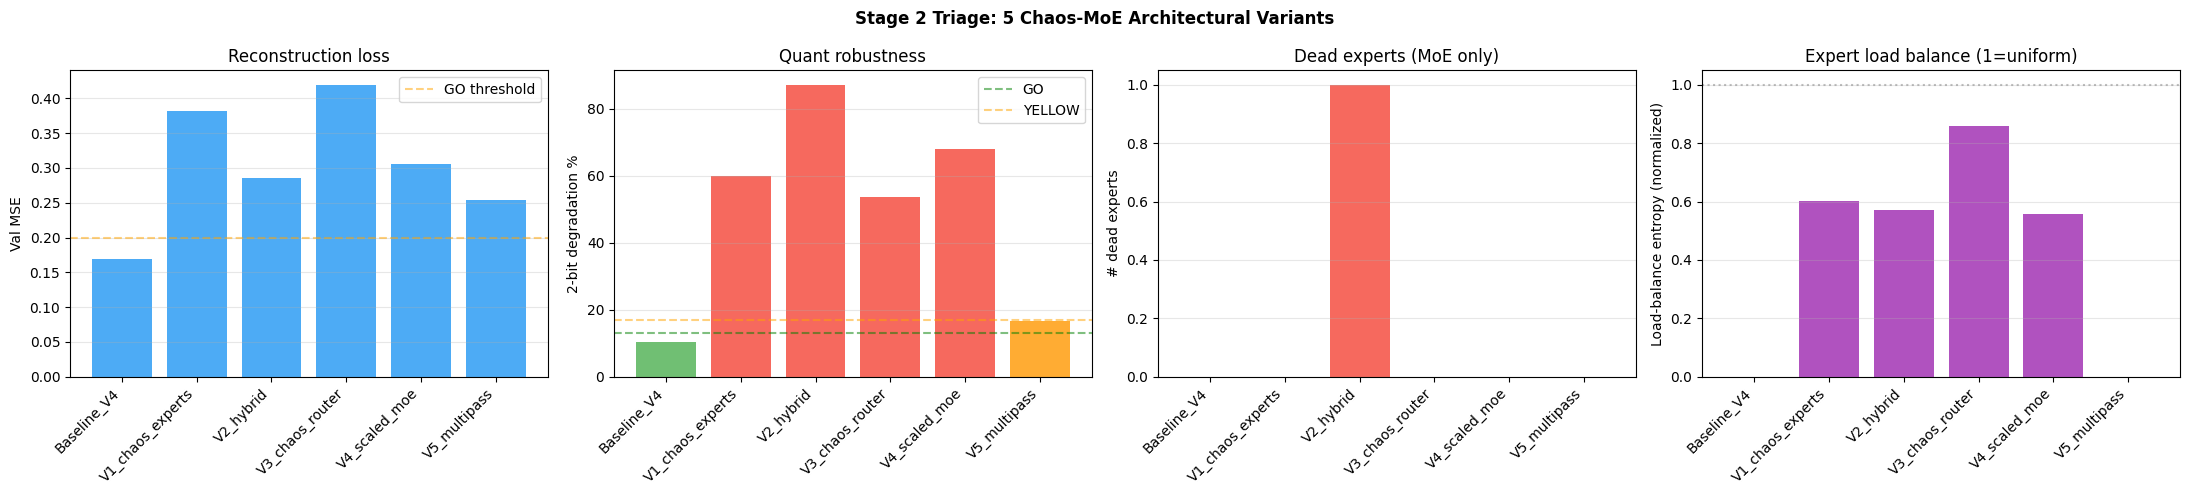

In [13]:
# Визуализация: 4 panel
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

names = list(summary.keys())
xs = range(len(names))

# (a) val loss
vls = [summary[n]['val_loss'] for n in names]
axes[0].bar(xs, vls, color='#2196F3', alpha=0.8)
axes[0].set_xticks(xs)
axes[0].set_xticklabels(names, rotation=45, ha='right')
axes[0].set_ylabel('Val MSE')
axes[0].set_title('Reconstruction loss')
axes[0].axhline(y=0.20, color='orange', linestyle='--', alpha=0.5, label='GO threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# (b) 2-bit deg
degs = [summary[n]['2bit_deg'] for n in names]
colors = ['#4CAF50' if summary[n]['verdict'] == 'GO' else
          '#FF9800' if summary[n]['verdict'] == 'YELLOW' else '#F44336'
          for n in names]
axes[1].bar(xs, degs, color=colors, alpha=0.8)
axes[1].set_xticks(xs)
axes[1].set_xticklabels(names, rotation=45, ha='right')
axes[1].set_ylabel('2-bit degradation %')
axes[1].set_title('Quant robustness')
axes[1].axhline(y=13, color='green', linestyle='--', alpha=0.5, label='GO')
axes[1].axhline(y=17, color='orange', linestyle='--', alpha=0.5, label='YELLOW')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# (c) dead experts
axes[2].set_title('Dead experts (MoE only)')
de = [(summary[n]['dead_experts'] or 0) for n in names]
axes[2].bar(xs, de, color='#F44336', alpha=0.8)
axes[2].set_xticks(xs)
axes[2].set_xticklabels(names, rotation=45, ha='right')
axes[2].set_ylabel('# dead experts')
axes[2].grid(True, alpha=0.3, axis='y')

# (d) expert entropy
ents = [(summary[n]['expert_entropy'] or 0) for n in names]
axes[3].bar(xs, ents, color='#9C27B0', alpha=0.8)
axes[3].set_xticks(xs)
axes[3].set_xticklabels(names, rotation=45, ha='right')
axes[3].set_ylabel('Load-balance entropy (normalized)')
axes[3].set_title('Expert load balance (1=uniform)')
axes[3].axhline(y=1.0, color='gray', linestyle=':', alpha=0.5)
axes[3].grid(True, alpha=0.3, axis='y')

plt.suptitle('Stage 2 Triage: 5 Chaos-MoE Architectural Variants', fontweight='bold')
plt.tight_layout()
plt.savefig(ARCH_DIR / 'chaos_moe_variants_summary.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Сохранение результатов

In [14]:
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
out = {
    'experiment': 'chaos_moe_variants_stage2_triage',
    'timestamp': ts,
    'config': {
        'input_dim': INPUT_DIM, 'latent_dim': LATENT_DIM, 'k_active': K_ACTIVE,
        'num_experts': NUM_EXPERTS, 'top_k_experts': TOP_K_EXPERTS,
        'inner_mult': INNER_MULT, 'epochs': EPOCHS, 'batch_size': BATCH_SIZE,
    },
    'results': {k: v for k, v in results_all.items()},
    'summary': summary,
}

out_file = JSONS_DIR / f'chaos_moe_variants_{ts}.json'
with open(out_file, 'w') as f:
    json.dump(out, f, indent=2, default=float)
print(f'Saved: {out_file}')

Saved: /Users/savenkovviktor/Documents/GitHub/k-sparse-chaos-autoencoder/jsons/chaos_moe_variants_20260424_024220.json


## 12. Вердикт и следующий шаг

**Что смотрим:**

1. **Variant 1 — GO или NO-GO?** Главный кандидат. Если `val_loss ≤ 0.20` и `2-bit deg ≤ 13%` при `dead_experts=0` → это тот самый результат, ради которого делали Stage 2

2. **Сравнение V1 (chaos experts) vs V2 (standard experts)** — это прямой ablation «даёт ли chaos в экспертах пользу». Если V2 догоняет V1, то chaos в MoE декоративен

3. **Dead experts** — ключевая новая метрика. Baseline ожидания:
   - Standard GELU + softmax MoE: обычно 10-30% dead experts (известная проблема)
   - Chaos MoE: ожидаем <10% (гипотеза!)

4. **Expert entropy** — load balancing:
   - 1.0 = идеально равномерное использование
   - <0.5 = router collapse (плохо)

5. **V4_scaled_moe** — контрольная точка. Ожидаем повторение проблемы из 02 (scaled residual ухудшает loss без пользы)

**Следующий шаг зависит от исхода:**

- **V1 = GO и dead_experts=0 при V2 > 0:** это основной публикуемый результат. Полный 5-seed ablation + масштабирование на Pythia-1.4B → workshop submission
- **V1 = GO но dead_experts как у V2:** chaos не решает dead-expert specifically, но даёт quant-friendliness. Менее sexy, но всё ещё публикуемо
- **V1 = NO-GO:** смотрим V2/V3/V5. Если хоть один GO — используем его. Если все NO-GO — возвращаемся к базовой Stage 1 идее (chaos-SAE без MoE и loops) и фокусируемся на sharpening теории + SOTA comparisons